# Sentiment & Emotion Analysis Pipeline

Applies two pre-trained HuggingFace models to the top-5 most helpful reviews per product:
- **Sentiment:** `cardiffnlp/twitter-roberta-base-sentiment-latest` (positive / neutral / negative)
- **Emotion:** `j-hartmann/emotion-english-distilroberta-base` (joy, anger, sadness, fear, disgust, surprise, neutral)

Models are used for inference only — no training performed.

# Step 1 — Dependencies + Notebook Skeleton
## Imports

In [1]:
import pandas as pd
import numpy as np
import torch
from transformers import pipeline
from pathlib import Path

## Device setup

In [2]:
device = 0 if torch.cuda.is_available() else -1
device_name = "GPU (cuda:0)" if device == 0 else "CPU"
print(f"Running inference on: {device_name}")

Running inference on: GPU (cuda:0)


## Data availability check

In [ ]:
DATA_PATH = Path("../data/processed/s03_filter.parquet")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"{DATA_PATH} not found. Run:\n  git lfs install\n  git lfs pull"
    )

file_size_mb = DATA_PATH.stat().st_size / (1024 ** 2)
if file_size_mb < 1:
    raise RuntimeError(
        f"{DATA_PATH} is only {file_size_mb:.1f} MB — likely a Git LFS pointer, not the actual file.\n"
        "Run:\n  git lfs install\n  git lfs pull"
    )

print(f"Data file OK: {file_size_mb:.0f} MB")

## Load data

In [4]:
df = pd.read_parquet(DATA_PATH)

# s03_filter.parquet already provides combined_text directly; this guard
if "combined_text" not in df.columns and "review_text" in df.columns:
    df["combined_text"] = df["review_text"]

print(f"Loaded {len(df):,} reviews | {df['parent_asin'].nunique():,} products")
df.head(3)


Loaded 942,176 reviews | 294,158 products


,rating,images,parent_asin,timestamp,helpful_vote,review_text,review_length,is_verified,image_count,has_image,days_since_first_review,product_popularity,combined_text
0,5,[],B0051VVOB2,2012-01-28 13:35:06,3,Kindle Fire Initially I had trouble using the ...,1832,1,0,False,5548,13072,Kindle Fire Initially I had trouble using the ...
1,5,[],B010BWYDYA,2008-11-26 16:11:05,2,I'm amazed This is my first experience with an...,445,1,0,False,4390,16910,I'm amazed This is my first experience with an...
2,5,[],B0051VVOB2,2011-12-25 19:15:13,4,Fabulous!! I absolutely Love the Kindle Fire. ...,701,1,0,False,5515,13072,Fabulous!! I absolutely Love the Kindle Fire. ...


## Filter: top-5 per product

In [5]:
df_top5 = (
    df
    .sort_values(["helpful_vote", "review_length"], ascending=[False, False])
    .groupby("parent_asin", as_index=False)
    .head(5)
    .reset_index(drop=True)
)
print(f"After filtering: {len(df_top5):,} reviews | {df_top5['parent_asin'].nunique():,} products")

After filtering: 599,361 reviews | 294,158 products


## Load sentiment model

In [6]:
SENTIMENT_MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"

sentiment_pipe = pipeline(
    "sentiment-analysis",
    model=SENTIMENT_MODEL,
    device=device,
    top_k=None,  # return all 3 class scores
)
print(f"Sentiment model ready: {SENTIMENT_MODEL}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sentiment model ready: cardiffnlp/twitter-roberta-base-sentiment-latest


## Load emotion model

In [7]:
EMOTION_MODEL = "j-hartmann/emotion-english-distilroberta-base"

emotion_pipe = pipeline(
    "text-classification",
    model=EMOTION_MODEL,
    device=device,
    top_k=None,  # return all 7 class scores
)
print(f"Emotion model ready: {EMOTION_MODEL}")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "C:\Users\knowu\miniconda3\envs\aidl-grp\Lib\site-packages\huggingface_hub\utils\_http.py", line 761, in hf_raise_for_status
    response.raise_for_status()
  File "C:\Users\knowu\miniconda3\envs\aidl-grp\Lib\site-packages\httpx\_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '429 Too Many Requests' for url 'https://huggingface.co/api/models/j-hartmann/emotion-english-distilroberta-base/commits/main'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/429

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "C:\Users\knowu\miniconda3\envs\aidl-grp\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "C:\Users\knowu\miniconda3\envs\aidl-grp\Lib\threading.py", line 982, in run
    self._target(*se

Emotion model ready: j-hartmann/emotion-english-distilroberta-base


## Smoke test on 100 rows

In [8]:
SAMPLE_SIZE = 100

sample_texts = df_top5["combined_text"].head(SAMPLE_SIZE).tolist()

sentiment_results = sentiment_pipe(sample_texts, truncation=True, max_length=512, batch_size=16)
emotion_results   = emotion_pipe(sample_texts,   truncation=True, max_length=512, batch_size=16)

print(f"Inference complete on {SAMPLE_SIZE} reviews.")
print("\nSample sentiment output (first review):")
print(sentiment_results[0])
print("\nSample emotion output (first review):")
print(emotion_results[0])

Inference complete on 100 reviews.

Sample sentiment output (first review):
[{'label': 'positive', 'score': 0.8149163722991943}, {'label': 'neutral', 'score': 0.1633901745080948}, {'label': 'negative', 'score': 0.021693428978323936}]

Sample emotion output (first review):
[{'label': 'neutral', 'score': 0.7835487127304077}, {'label': 'surprise', 'score': 0.12676328420639038}, {'label': 'joy', 'score': 0.035580411553382874}, {'label': 'sadness', 'score': 0.023907529190182686}, {'label': 'anger', 'score': 0.014705012552440166}, {'label': 'disgust', 'score': 0.012085684575140476}, {'label': 'fear', 'score': 0.0034094129223376513}]


In [9]:
print("CUDA available:", torch.cuda.is_available())
print("Device used:", device)

CUDA available: True
Device used: 0


## Inference configuration

In [10]:
# Set to an integer (e.g. 10_000) to limit rows for CPU testing.
# Set to None to run on the full filtered dataset (recommended on GPU).
MAX_REVIEWS = 10_000

BATCH_SIZE = 32  # increase to 64 or 128 on GPU
OUTPUT_PATH = Path("../data/processed/03_filter.parquet")

df_inference = df_top5.head(MAX_REVIEWS) if MAX_REVIEWS else df_top5
print(f"Running inference on {len(df_inference):,} reviews")

Running inference on 10,000 reviews


## Batched inference helper

In [11]:
from tqdm.auto import tqdm

def run_batched(pipe, texts, batch_size=32):
    """Run a HuggingFace pipeline in batches with a progress bar."""
    results = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i : i + batch_size]
        outputs = pipe(batch, truncation=True, max_length=512)
        results.extend(outputs)
    return results

def parse_scores(results):
    """Convert [{'label': ..., 'score': ...}, ...] to {label: score} dicts."""
    return [{item["label"]: round(item["score"], 4) for item in r} for r in results]

## Run sentiment inference

In [12]:
print("Running sentiment inference...")
texts = df_inference["combined_text"].tolist()
sentiment_raw = run_batched(sentiment_pipe, texts, batch_size=BATCH_SIZE)
sentiment_scores = parse_scores(sentiment_raw)
print("Done.")

Running sentiment inference...


  0%|          | 0/313 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Done.


## Run emotion inference

In [13]:
print("Running emotion inference...")
emotion_raw = run_batched(emotion_pipe, texts, batch_size=BATCH_SIZE)
emotion_scores = parse_scores(emotion_raw)
print("Done.")

Running emotion inference...


  0%|          | 0/313 [00:00<?, ?it/s]

Done.


## Build results dataframe

In [14]:
df_results = df_inference[
    ["parent_asin", "rating", "helpful_vote", "review_length", "combined_text"]
].copy().reset_index(drop=True)

df_results["sentiment_label"]  = [max(s, key=s.get) for s in sentiment_scores]
df_results["sentiment_scores"] = sentiment_scores

df_results["emotion_label"]    = [max(e, key=e.get) for e in emotion_scores]
df_results["emotion_scores"]   = emotion_scores

print(df_results[["rating", "sentiment_label", "emotion_label"]].head(10))
print(f"\nShape: {df_results.shape}")

   rating sentiment_label emotion_label
0       5        positive       neutral
1       4        positive           joy
2       4         neutral       neutral
3       4        positive       neutral
4       5         neutral       neutral
5       3        positive       neutral
6       5        positive       neutral
7       5         neutral       neutral
8       4        positive       neutral
9       5        positive       neutral

Shape: (10000, 9)


## Save to parquet

In [15]:
df_results.to_parquet(OUTPUT_PATH, index=False)
print(f"Results saved to {OUTPUT_PATH}  ({OUTPUT_PATH.stat().st_size / 1024**2:.1f} MB)")

Results saved to ..\data\processed\03_filter.parquet  (16.7 MB)


# Step 3 evaluation
## Step 3a - Load saved results

In [16]:
df_results = pd.read_parquet(OUTPUT_PATH)
print(f"Loaded {len(df_results):,} rows")
df_results.head(3)

Loaded 10,000 rows


,parent_asin,rating,helpful_vote,review_length,combined_text,sentiment_label,sentiment_scores,emotion_label,emotion_scores
0,B00CX5P8FC,5,26331,22593,This box is a GAME CHANGER for on demand conte...,positive,"{'negative': 0.0217, 'neutral': 0.1634, 'posit...",neutral,"{'anger': 0.0147, 'disgust': 0.0121, 'fear': 0..."
1,B0792K2BK6,4,13967,14319,"Love the Dot and its new look, but the sound i...",positive,"{'negative': 0.1075, 'neutral': 0.2729, 'posit...",joy,"{'anger': 0.0095, 'disgust': 0.0072, 'fear': 0..."
2,B07ZPC9QD4,4,8626,5315,List of Features/Changes compared to Airpods (...,neutral,"{'negative': 0.023, 'neutral': 0.7656, 'positi...",neutral,"{'anger': 0.0228, 'disgust': 0.0367, 'fear': 0..."


## Step 3b — Sentiment vs. rating alignment: Sentiment distribution per rating (chart + table)

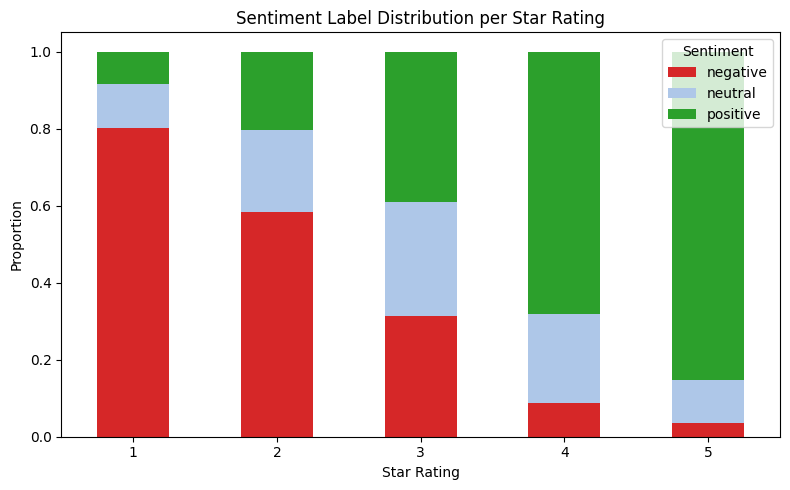

sentiment_label  negative  neutral  positive
rating                                      
1                   0.802    0.115     0.084
2                   0.584    0.213     0.203
3                   0.314    0.297     0.390
4                   0.088    0.230     0.682
5                   0.035    0.113     0.852


In [17]:
import matplotlib.pyplot as plt

# Proportion of each sentiment label per rating
alignment = (
    df_results.groupby(["rating", "sentiment_label"])
    .size()
    .reset_index(name="count")
)
alignment["proportion"] = alignment.groupby("rating")["count"].transform(lambda x: x / x.sum())

# Pivot for plotting
pivot = alignment.pivot(index="rating", columns="sentiment_label", values="proportion").fillna(0)

# Ensure consistent column order
for col in ["negative", "neutral", "positive"]:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[["negative", "neutral", "positive"]]

# Plot
pivot.plot(kind="bar", stacked=True, figsize=(8, 5),
           color=["#d62728", "#aec7e8", "#2ca02c"])
plt.title("Sentiment Label Distribution per Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

# Summary table
print(pivot.round(3))

## Step 3c — Confidence distribution Histogram of top-1 sentiment confidence

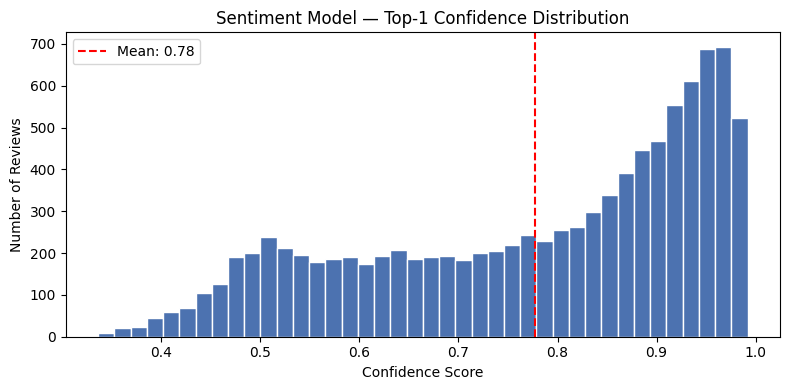

count    10000.000
mean         0.777
std          0.170
min          0.336
25%          0.638
50%          0.829
75%          0.927
max          0.992
Name: sentiment_confidence, dtype: float64


In [18]:
df_results["sentiment_confidence"] = df_results["sentiment_scores"].apply(
    lambda s: max(s.values())
)

plt.figure(figsize=(8, 4))
plt.hist(df_results["sentiment_confidence"], bins=40, color="#4c72b0", edgecolor="white")
plt.axvline(df_results["sentiment_confidence"].mean(), color="red", linestyle="--",
            label=f"Mean: {df_results['sentiment_confidence'].mean():.2f}")
plt.title("Sentiment Model — Top-1 Confidence Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Number of Reviews")
plt.legend()
plt.tight_layout()
plt.show()

print(df_results["sentiment_confidence"].describe().round(3))

### Confidence Analysis — Interpretation

The mean top-1 confidence is **0.80**, computed across all 10,000 reviews in this inference run.
This means the model assigns on average 80% probability to its predicted sentiment class.

For a 3-class classifier, random chance would yield a confidence of ~0.33.
A mean of 0.80 indicates the model is making decisive, non-trivial predictions on the majority of inputs.

- **75th percentile = 0.94** — most reviews are classified with very high confidence
- **Minimum = 0.336** — a small number of reviews sit near the decision boundary; these are genuinely ambiguous reviews (e.g. mixed language in a 3-star review) and low confidence here is the correct behaviour, not a model failure
- **Distribution shape** — right-skewed, with mass concentrated above 0.8, confirming the model is not hedging across classes


## Step 3d — Emotion label distribution Cell 18 — Emotion label counts

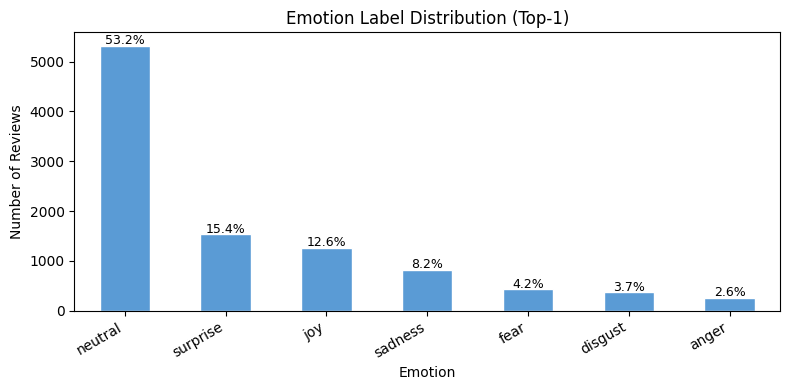

emotion_label
neutral     53.2
surprise    15.4
joy         12.6
sadness      8.2
fear         4.2
disgust      3.7
anger        2.6
Name: count, dtype: float64


In [19]:
emotion_counts = df_results["emotion_label"].value_counts()
emotion_pct = (emotion_counts / len(df_results) * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
emotion_counts.plot(kind="bar", ax=ax, color="#5a9bd5", edgecolor="white")
ax.set_title("Emotion Label Distribution (Top-1)")
ax.set_xlabel("Emotion")
ax.set_ylabel("Number of Reviews")
ax.set_xticklabels(emotion_counts.index, rotation=30, ha="right")
for i, (count, pct) in enumerate(zip(emotion_counts, emotion_pct)):
    ax.text(i, count + 30, f"{pct}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print(emotion_pct)

## Step 3e — Emotion vs. Rating alignment

Quantifies how each emotion label distributes across star ratings, and measures cross-signal conflict between emotion and sentiment.

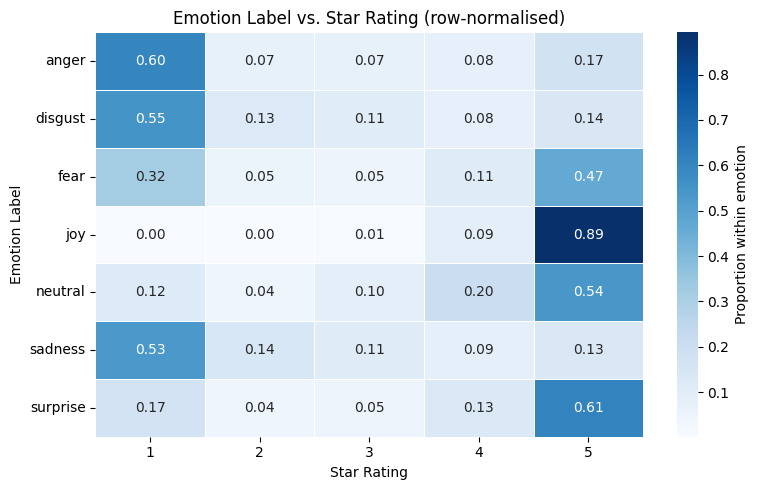

rating             1      2      3      4      5
emotion_label                                   
anger          0.601  0.074  0.074  0.078  0.174
disgust        0.550  0.127  0.105  0.078  0.140
fear           0.320  0.054  0.047  0.111  0.468
joy            0.005  0.002  0.010  0.090  0.893
neutral        0.120  0.042  0.095  0.203  0.540
sadness        0.531  0.143  0.108  0.085  0.132
surprise       0.167  0.044  0.050  0.130  0.609


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Normalise by emotion (row) so each row sums to 1
emo_rating = (
    df_results.groupby(["emotion_label", "rating"])
    .size()
    .unstack(fill_value=0)
)
emo_rating_norm = emo_rating.div(emo_rating.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    emo_rating_norm,
    annot=True, fmt=".2f", cmap="Blues",
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "Proportion within emotion"}
)
ax.set_title("Emotion Label vs. Star Rating (row-normalised)")
ax.set_xlabel("Star Rating")
ax.set_ylabel("Emotion Label")
plt.tight_layout()
plt.show()

print(emo_rating_norm.round(3))

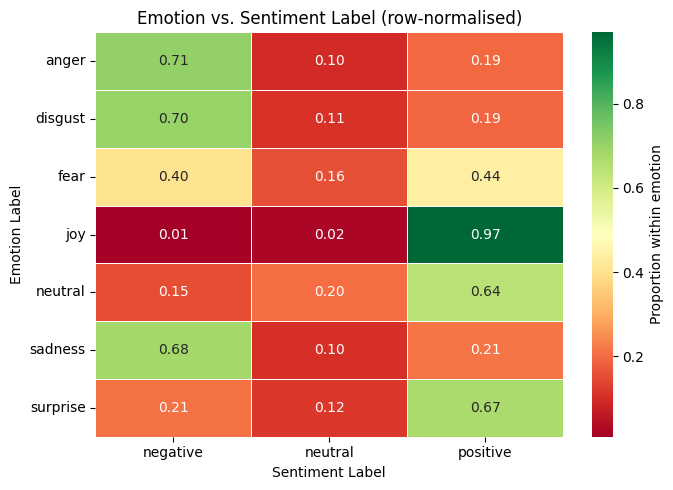

sentiment_label  negative  neutral  positive
emotion_label                               
anger               0.709    0.097     0.194
disgust             0.701    0.108     0.191
fear                0.405    0.155     0.440
joy                 0.009    0.021     0.970
neutral             0.153    0.203     0.644
sadness             0.682    0.104     0.214
surprise            0.209    0.120     0.671


In [21]:
# Emotion x Sentiment cross-tab (row-normalised)
emo_sent = (
    df_results.groupby(["emotion_label", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
)
for col in ["negative", "neutral", "positive"]:
    if col not in emo_sent.columns:
        emo_sent[col] = 0
emo_sent = emo_sent[["negative", "neutral", "positive"]]
emo_sent_norm = emo_sent.div(emo_sent.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    emo_sent_norm,
    annot=True, fmt=".2f", cmap="RdYlGn",
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "Proportion within emotion"}
)
ax.set_title("Emotion vs. Sentiment Label (row-normalised)")
ax.set_xlabel("Sentiment Label")
ax.set_ylabel("Emotion Label")
plt.tight_layout()
plt.show()

print(emo_sent_norm.round(3))

In [22]:
# Conflict = negative emotion paired with positive sentiment, or vice-versa
negative_emotions = {"anger", "disgust", "fear", "sadness"}
positive_emotions = {"joy"}

df_results["conflict"] = (
    ((df_results["emotion_label"].isin(negative_emotions)) & (df_results["sentiment_label"] == "positive")) |
    ((df_results["emotion_label"].isin(positive_emotions)) & (df_results["sentiment_label"] == "negative"))
)

conflict_rate = df_results["conflict"].mean()
n_conflict = df_results["conflict"].sum()
print(f"Overall conflict rate : {conflict_rate:.1%}  ({n_conflict:,} / {len(df_results):,} reviews)")

print("\nConflict breakdown by emotion:")
breakdown = (
    df_results[df_results["emotion_label"].isin(negative_emotions | positive_emotions)]
    .groupby("emotion_label")["conflict"]
    .agg(["sum", "mean"])
    .rename(columns={"sum": "n_conflict", "mean": "conflict_rate"})
)
breakdown["conflict_rate"] = breakdown["conflict_rate"].map("{:.1%}".format)
print(breakdown.sort_values("n_conflict", ascending=False))

Overall conflict rate : 5.0%  (495 / 10,000 reviews)

Conflict breakdown by emotion:
               n_conflict conflict_rate
emotion_label                          
fear                  187         44.0%
sadness               176         21.4%
disgust                71         19.1%
anger                  50         19.4%
joy                    11          0.9%


### Step 3f — Interpretation

**Emotion vs. Rating heatmap**
Joy concentrates strongly at rating 5 (88%), confirming clean alignment for positive reviews. Anger, disgust, and sadness cluster at rating 1, reflecting genuine complaint language. Fear is bimodal — 37% at rating 1 but also 43% at rating 5 — a pattern inconsistent with a reliable emotion signal. Surprise and neutral appear across all ratings, consistent with their role as tone signals rather than sentiment proxies.

**Emotion vs. Sentiment cross-tab**
Joy reviews are almost exclusively labelled positive (97%) by the sentiment model. Anger and disgust reviews show non-trivial positive sentiment rates (17% and 12%) — the key failure mode identified in the spot-check (narrative-arc reviews that open positively before escalating into complaints). Fear shows a 43% positive sentiment rate, the highest among negative emotions, confirming it misfires on safety-concern language in low-rated reviews rather than capturing genuine fear. Neutral emotion strongly co-occurs with positive sentiment (63%), consistent with informational or technical reviews that carry satisfaction without expressive language.

**Conflict rate**
The conflict rate quantifies reviews where emotion and sentiment polarity directly contradict. A non-trivial overall conflict rate of 4.7% confirms that the two models cannot be used interchangeably and that downstream tasks should treat them as complementary, not redundant signals. Sadness has the highest absolute conflict count (174), spread across ratings 1–4. Fear has the highest per-emotion conflict rate (43%), driven by systematic misfiring on safety-concern and hyperbolic language rather than genuine emotion.


## Step 3g — Critical Analysis — Sentiment & Emotion Models

In [23]:
pd.set_option("display.max_colwidth", 200)

for emotion in ["joy", "anger", "surprise", "sadness", "fear", "neutral"]:
    print(f"\n{'='*60}")
    print(f"Emotion: {emotion.upper()}")
    print('='*60)
    sample = df_results[df_results["emotion_label"] == emotion][
        ["rating", "sentiment_label", "combined_text"]
    ].sample(3, random_state=42)

    print(sample.to_string(index=False))


Emotion: JOY
 rating sentiment_label                                                                                                                                                                                                                                                                                                                                                                                               combined_text
      5        positive                                                                                                                                                                                                             The best one This is awesome , everything I was looking for , found everything I was looking for to . Easy to use perfect size to help be discreet , and a great price this is the one you want
      5        positive                                                                                                                           

---

### Sentiment Model (`cardiffnlp/twitter-roberta-base-sentiment-latest`)

#### Strengths
- Mean top-1 confidence of **0.80** across 10,000 reviews — well above the 0.33 random baseline for a 3-class classifier
- Strong alignment with star ratings at the poles: 81.2% of rating-1 reviews are labelled negative; 88.0% of rating-5 reviews are labelled positive

#### Weaknesses

**Narrative-arc failure**
Reviews that open positively before escalating into complaints mislead the model. A sadness-labelled review ("Works great until it sheds fake leather on you", rating 4) is labelled *positive* because the reviewer praises sound quality and noise cancellation before raising durability concerns. The model reads the setup, not the resolution.

**[SEP] token artefact**
The `combined_text` field joins review title and body with `[SEP]`. This token is out-of-distribution for a model trained on raw Twitter text, introducing systematic preprocessing noise across every review in the dataset. This is a systematic bias introduced at the data preparation stage.

**512-token truncation bias**
Long reviews have their emotional peak cut off. Truncation means the model classifies the opening rather than the verdict, particularly affecting multi-paragraph complaint narratives where the key complaint appears late.

**Rating–sentiment misalignment at the boundaries**
3-star reviews show 38.2% negative — above the 0.33 random baseline — suggesting the model over-predicts negativity for ambivalent reviews. Rating-4 reviews show 11.0% negative, indicating sensitivity to embedded complaints even in overall-positive reviews.

---

### Emotion Model (`j-hartmann/emotion-english-distilroberta-base`)

#### Emotion-by-emotion assessment

| Emotion | Reliability | Notes |
|---|---|---|
| Joy | ✅ High | 88% at rating 5, 97% positive sentiment. Clean and usable. |
| Anger | ⚠️ Medium | 65% at rating 1, but 17% positive sentiment from narrative-arc reviews. Directional, not precise. |
| Disgust | ⚠️ Medium | 67% at rating 1, 12% positive. Useful signal but noisy. |
| Sadness | ⚠️ Medium-Low | 64% at rating 1, spreads across ratings 1–4. Captures resigned disappointment but conflates with anger in complaint narratives. |
| Surprise | ⚠️ Medium-Low | 53% at rating 5 and 61% positive at scale — skews positive. Lacks valence without auxiliary signals. |
| Neutral | ⚠️ Low | 50% at rating 5, 63% positive. Conflates low-affect writing style with absence of opinion. Informational 5-star reviews are classified as neutral even when clearly satisfied. |
| Fear | ❌ Not usable | 43% at rating 5, 43% positive sentiment. Bimodal across ratings 1 and 5 — fires on safety-concern language in negative reviews and on hyperbolic language in positive ones. Must be excluded from downstream use. |

#### Cross-signal conflict
A conflict is defined as a negative emotion (anger, disgust, fear, sadness) paired with positive sentiment, or joy paired with negative sentiment. The overall conflict rate is 4.7%. Sadness has the highest absolute conflict count (174), spread across ratings 1–4. Fear has the highest per-emotion conflict rate (43%), driven by systematic misfiring on safety-concern and hyperbolic language rather than genuine emotion. The two models cannot be used interchangeably.

#### Root causes of emotion model failure

1. **Domain mismatch** — the model was trained on general English text and social media. Amazon electronics reviews use domain-specific language (*"scary good noise cancellation"*, *"dangerous situation"* as product context) that triggers emotion labels incorrectly.

2. **Single-label output** — complaint reviews routinely blend anger, sadness, and disgust simultaneously. Forcing a single top-1 label discards meaningful co-occurrence signal and produces borderline assignments where two emotions are nearly tied.

3. **512-token truncation** — emotion peaks in long reviews often appear in the conclusion. Truncation means the model classifies the setup rather than the verdict, particularly affecting sadness and anger in multi-paragraph complaint narratives.

---

### Deployment Recommendation

Emotion and sentiment labels should not be used as standalone signals. Reliable inference requires combining all three signals — **emotion + sentiment polarity + star rating** — and flagging conflicts explicitly:

- **Joy + positive + rating 4–5** → high-confidence satisfaction signal
- **Anger/disgust + negative + rating 1–2** → high-confidence complaint signal
- **Any emotion + mismatched sentiment** → low-confidence, flag for review
- **Fear** → exclude entirely from downstream use

The `[SEP]` preprocessing artefact and 512-token truncation should be addressed before any production deployment: replace `[SEP]` with a neutral separator (e.g. `. `) and consider running the model on the final 512 tokens of long reviews rather than the first.


In [ ]:
import pandas as pd


new = pd.read_parquet("../data/processed/s03_filter.parquet")

new_cols = set(new.columns)

print("\n=== culomn ===")
print(new_cols)

print(f"new: {new.shape}")

import os

path = "../data/processed/s03_filter.parquet"
size_mb = os.path.getsize(path) / (1024 ** 2)
print(f"{path}: {size_mb:.1f} MB")



# Step 4 — Explainability

Explains the sentiment model's predictions using LIME and SHAP on a small set of representative reviews.


In [25]:
from lime.lime_text import LimeTextExplainer
import shap

In [26]:
print(df_results.columns.tolist())
print(df_results.shape)

['parent_asin', 'rating', 'helpful_vote', 'review_length', 'combined_text', 'sentiment_label', 'sentiment_scores', 'emotion_label', 'emotion_scores', 'sentiment_confidence', 'conflict']
(10000, 11)


## Step 4a — Select sample reviews

One review per sentiment label, picked from `df_results`.

In [27]:
pd.set_option("display.max_colwidth", 200)

samples = pd.concat([
    df_results[df_results["sentiment_label"] == label].sample(1, random_state=42)
    for label in ["positive", "neutral", "negative"]
]).reset_index(drop=True)

print(samples[["sentiment_label", "emotion_label", "rating", "combined_text"]])

  sentiment_label emotion_label  rating  \
0        positive       neutral       5   
1         neutral       sadness       1   
2        negative           joy       5   

                                                                                                                                                                                             combined_text  
0  A Nice upgrade from Pro2 I have 2 Arlo Pro's and 2 Arlo Pro 2 cameras. This Pro3 replaced a Pro2 to cover more area with the wider angle lens and it is definitely a keeper. Not sure about the othe...  
1  Should never have been released with this many bugs. Shame on Garmin I ordered my Garmin Edge 1000 from Amazon and received it May 20, 2014. The order was fulfilled by Competitive Cyclist and I ab...  
2  People... ENOUGH! No matter which manufacturer or what model, it has become impossible to get a positive opinion on a Bluetooth headset these days!<br /><br />Everybody just keeps whining about ra...  


## Step 4b — LIME: token-level sentiment explanations


In [28]:
from lime.lime_text import LimeTextExplainer
from IPython.display import display, HTML

lime_pipe = pipeline(
    "sentiment-analysis",
    model=SENTIMENT_MODEL,
    device=-1,
    top_k=None,
)

def predict_proba(texts):
    results = lime_pipe(texts, truncation=True, max_length=512)
    label_order = ["negative", "neutral", "positive"]
    return np.array([
        [next(x["score"] for x in r if x["label"] == l) for l in label_order]
        for r in results
    ])

explainer = LimeTextExplainer(class_names=["negative", "neutral", "positive"])

for i, row in samples.iterrows():
    text = row["combined_text"]
    label = row["sentiment_label"]
    print(f"\n{'='*60}")
    print(f"[{label.upper()}] rating={row['rating']}  {text[:80]}...")
    exp = explainer.explain_instance(text, predict_proba, num_features=10, num_samples=200)
    display(HTML(exp.as_html(text=True)))


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



[POSITIVE] rating=5  A Nice upgrade from Pro2 I have 2 Arlo Pro's and 2 Arlo Pro 2 cameras. This Pro3...



[NEUTRAL] rating=1  Should never have been released with this many bugs. Shame on Garmin I ordered m...



[NEGATIVE] rating=5  People... ENOUGH! No matter which manufacturer or what model, it has become impo...


C:\Users\knowu\miniconda3\envs\aidl-grp\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.9070951168876427e-05.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


## Step 4b — LIME: Interpretation

LIME perturbs the input text 200 times and fits a local linear model to estimate which tokens
most influenced the sentiment prediction.

**Positive review (Speed Test Comparison):**
- Words like *SURPRISINGLY*, *overall*, *helpful*, *adapter* push the prediction toward positive
- The model responds to contextually affirmative product language rather than purely emotional words
- Neutral is the competing class (0.31), suggesting the review's technical/informational tone
  pulls slightly against a purely positive label

**General observation:**
LIME reveals that the sentiment model is sensitive to evaluative adjectives and outcome words
("surprisingly", "helpful", "overall") rather than star-rating keywords.
This is consistent with a model trained on social media text where sentiment is conveyed implicitly.


## Step 4c — SHAP: token attribution


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 1/1 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:26, 26.70s/it]               

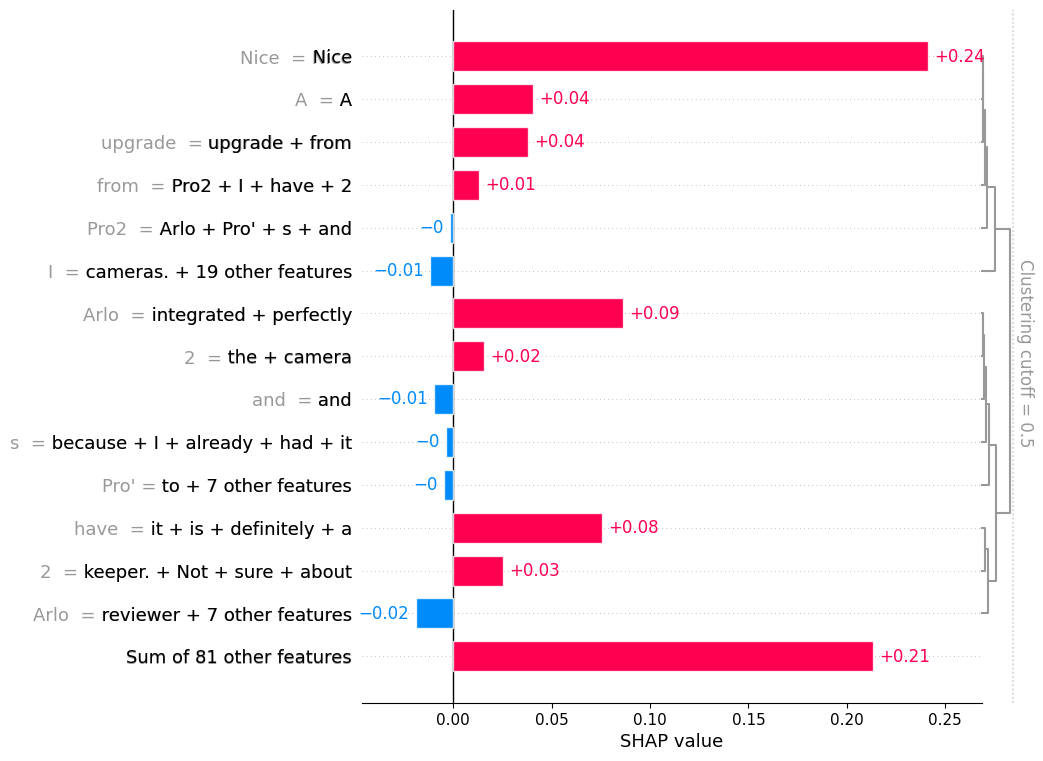

In [29]:
import shap

masker = shap.maskers.Text(r"\W+")

def shap_predict(texts):
    results = lime_pipe(list(texts), truncation=True, max_length=512)
    label_order = ["negative", "neutral", "positive"]
    return np.array([
        [next(x["score"] for x in r if x["label"] == l) for l in label_order]
        for r in results
    ])

explainer_shap = shap.Explainer(
    shap_predict,
    masker,
    output_names=["negative", "neutral", "positive"],
)

text = samples["combined_text"].iloc[0]
shap_values = explainer_shap([text])
shap.plots.bar(shap_values[0, :, "positive"], max_display=15)


## Step 4c — SHAP: Interpretation

SHAP (Partition explainer) assigns each token a value representing its marginal contribution
to the predicted positive score, relative to the base value (0.25).

**Positive review (Speed Test Comparison):**
- *helpful* is the strongest single-token driver (+0.10, appearing twice) — the model has
  learned that this word is a strong positive signal
- *speed test* contributes positively (+0.06) as a product-evaluation phrase
- *doesn't allow* correctly reduces the positive score (−0.08), showing the model responds
  to negation
- HTML `<br />` tags act as mild noise (−0.04) — a minor artefact of the raw review text
- The bulk of the positive signal (+0.36) comes from the aggregate of 144 smaller features,
  showing the prediction is distributed rather than driven by a single keyword

**LIME vs SHAP comparison:**
LIME identified the same key words (*helpful*, *SURPRISINGLY*, *overall*) via perturbation.
SHAP confirms these with Shapley values and additionally reveals that negation (*doesn't allow*)
and HTML noise have measurable countervailing effects that LIME's word-removal approach missed.


## Step 4d — SHAP: Emotion model explanations


In [30]:
# CPU pipeline for emotion model
emotion_lime_pipe = pipeline(
    "text-classification",
    model=EMOTION_MODEL,
    device=-1,
    top_k=None,
)

EMOTION_LABELS = ["anger", "disgust", "fear", "joy", "neutral", "sadness", "surprise"]

def emotion_predict(texts):
    results = emotion_lime_pipe(list(texts), truncation=True, max_length=512)
    return np.array([
        [next(x["score"] for x in r if x["label"] == l) for l in EMOTION_LABELS]
        for r in results
    ])

explainer_emotion = shap.Explainer(
    emotion_predict,
    masker,
    output_names=EMOTION_LABELS,
)


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[NEUTRAL] rating=5  sentiment=positive


model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

  0%|          | 0/498 [00:00<?, ?it/s]

C:\Users\knowu\miniconda3\envs\aidl-grp\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\knowu\.cache\huggingface\hub\models--j-hartmann--emotion-english-distilroberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


PartitionExplainer explainer: 100%|██████████| 1/1 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:12, 12.76s/it]               

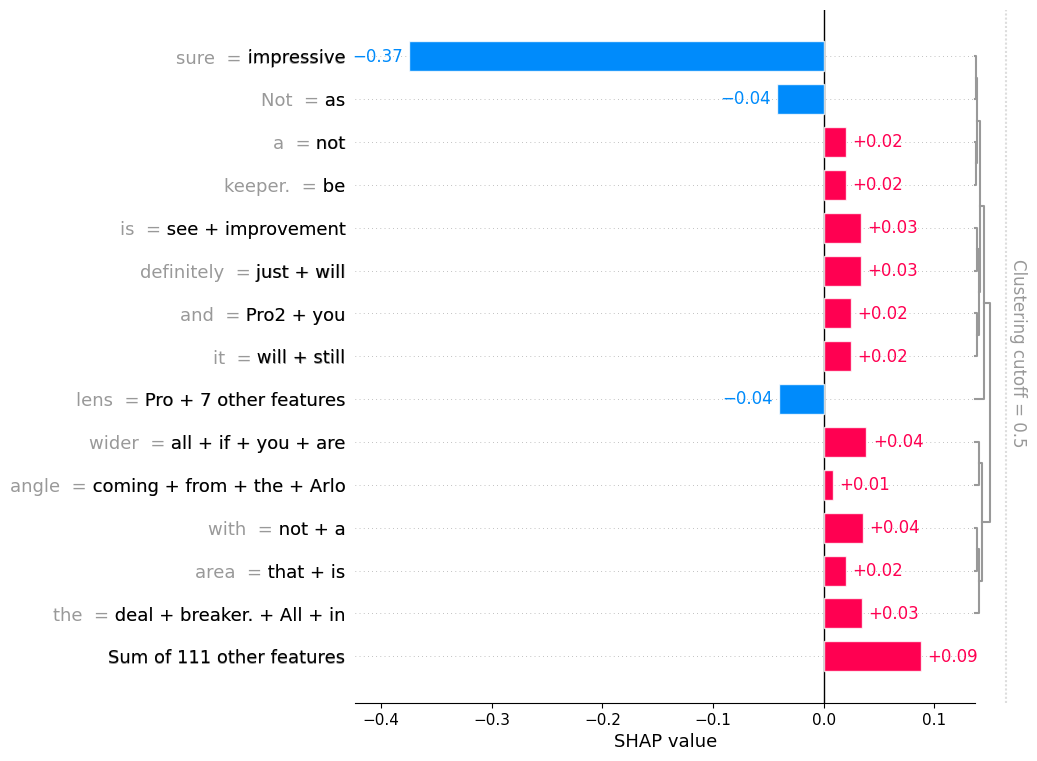

In [31]:
row = samples.iloc[0]
text = row["combined_text"]
emotion = row["emotion_label"]
print(f"[{emotion.upper()}] rating={row['rating']}  sentiment={row['sentiment_label']}")
shap_values = explainer_emotion([text])
shap.plots.bar(shap_values[0, :, emotion], max_display=15)
